# **Week 2**

Integrating multiple battery datasets to prepare machine learning ready dataset.

Datasets used:
- CALCE
- CALB
- Stanford
- NASA

Different formats handled:
- PKL
- MAT

Dataset Features:
- time
- voltage
- current
- temperature
- cycle
- dataset
- chemistry
- cell_id

Outputs:
- data_processed/dataset_metadata_fixed.csv
- data_processed/battery_master_dataset.parquet
- data_processed/battery_master_dataset.csv

Importing required libraries for dataset processing.

In [3]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import pickle
import scipy.io as sio

In [4]:
#Loading metadata 
RAW = Path("data_raw")
OUT = Path("data_processed")
OUT.mkdir(exist_ok=True)

# Trying common metadata locations first
candidates = [
    OUT / "dataset_metadata_fixed.csv",
    OUT / "dataset_metadata.csv",
    Path("metadata.csv"),
    Path("data_processed/dataset_metadata.csv"),
    Path("data_processed/metadata.csv")
]

metadata_df = None
for c in candidates:
    if c.exists():
        try:
            metadata_df = pd.read_csv(c)
            print("Loaded metadata from:", c)
            break
        except Exception:
            metadata_df = None

# If not found or loaded, rebuild by scanning data_raw/
if metadata_df is None:
    print("No usable saved metadata found. Rebuilding metadata by scanning data_raw/ ...")
    rows = []
    for p in RAW.rglob("*"):
        if p.suffix.lower() in (".pkl", ".mat"):
            pstr = str(p)
            pl = pstr.lower()
            ds = "Unknown"
            if "calce" in pl: ds = "CALCE"
            elif "calb" in pl: ds = "CALB"
            elif "stanford" in pl: ds = "Stanford"
            elif "nasa" in pl: ds = "NASA"
            rows.append({
                "dataset": ds,
                "file": pstr,
                "chemistry": "Unknown"
            })
    metadata_df = pd.DataFrame(rows)
    print(f"Rebuilt metadata with {len(metadata_df)} entries.")

# Displaying Dataset
display(metadata_df.head(10))
metadata_df.to_csv(OUT / "dataset_metadata_fixed.csv", index=False)
print("Saved fixed metadata to:", OUT / "dataset_metadata_fixed.csv")

Loaded metadata from: data_processed/dataset_metadata_fixed.csv


,dataset,file,chemistry
0,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B182.pkl,Unknown
1,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B183.pkl,Unknown
2,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B184.pkl,Unknown
3,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B185.pkl,Unknown
4,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B187.pkl,Unknown
5,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B188.pkl,Unknown
6,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B189.pkl,Unknown
7,CALB,data_raw/BatteryLife_CALB/CALB/CALB_0_B190.pkl,Unknown
8,CALB,data_raw/BatteryLife_CALB/CALB/CALB_25_T25-1.pkl,Unknown
9,CALB,data_raw/BatteryLife_CALB/CALB/CALB_25_T25-2.pkl,Unknown


Saved fixed metadata to: data_processed/dataset_metadata_fixed.csv


Showing counts of PKL / MAT files discovered and a small preview. 

In [5]:

dataset_files = [Path(f) for f in metadata_df['file'].dropna().tolist()]
pkl_files = [p for p in dataset_files if p.suffix.lower() == ".pkl"]
mat_files = [p for p in dataset_files if p.suffix.lower() == ".mat"]

print(f"PKL files found: {len(pkl_files)}")
print(f"MAT files found: {len(mat_files)}")
print("\nExample PKL:", pkl_files[0] if pkl_files else "none")
print("Example MAT:", mat_files[0] if mat_files else "none")

PKL files found: 81
MAT files found: 66

Example PKL: data_raw/BatteryLife_CALB/CALB/CALB_0_B182.pkl
Example MAT: data_raw/NASA_Battery_Data/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat


Defining safe helper functions that coerce many nested structures to 1D numeric arrays and heuristics to guess roles (time, voltage, current, temperature).

In [6]:
def to_numpy(x):
    """Convert nested structures to 1D numeric numpy array if possible."""
    if x is None:
        return np.array([])
    if isinstance(x, np.ndarray):
        if x.dtype == object:
            # flatten object array by extracting numeric parts
            elems = []
            for el in x.ravel():
                a = to_numpy(el)
                if a.size > 0:
                    elems.append(a)
            if elems:
                try:
                    return np.concatenate(elems)
                except Exception:
                    return elems[0]
            return np.array([])
        try:
            return x.astype(float).ravel()
        except Exception:
            try:
                return np.asarray(x.ravel(), dtype=float)
            except:
                return np.array([])
    if isinstance(x, (list, tuple)):
        flat = []
        for el in x:
            a = to_numpy(el)
            if a.size > 0:
                flat.append(a)
        if flat:
            try:
                return np.concatenate(flat)
            except:
                # fallback: try to convert list of scalars
                try:
                    return np.asarray([float(v) for v in x], dtype=float)
                except:
                    return np.array([])
        return np.array([])
    # pandas Series
    try:
        import pandas as pd
        if isinstance(x, pd.Series):
            return x.to_numpy(dtype=float).ravel()
    except:
        pass
    # scalar fallback
    try:
        return np.asarray([float(x)], dtype=float)
    except:
        return np.array([])

def is_time_array(a):
    """Heuristic: numeric, monotonic (non-decreasing), and reasonable length."""
    try:
        arr = np.asarray(a, dtype=float).ravel()
    except Exception:
        return False
    if arr.size < 5:
        return False
    if not np.all(np.isfinite(arr)):
        return False
    diffs = np.diff(arr)
    return np.all(diffs >= -1e-6)

def guess_signal_roles(candidates):
    """
    candidates: dict(name->array)
    returns mapping {'time':name or None, 'voltage':..., 'current':..., 'temperature':...}
    """
    roles = {'time':None,'voltage':None,'current':None,'temperature':None}
    # normalize
    norm = {}
    for k,v in candidates.items():
        arr = to_numpy(v)
        if arr.size > 2:
            norm[k] = arr
    if not norm:
        return roles
    # time via monotonicity
    for k,a in norm.items():
        if is_time_array(a):
            roles['time'] = k
            break
    # voltage via range
    for k,a in norm.items():
        mn, mx = float(np.nanmean(a)), float(np.nanmax(a))
        if roles['voltage'] is None and 1.0 < mn < 6.5 and mx < 12:
            roles['voltage'] = k
    # temperature via range
    for k,a in norm.items():
        mn, mx = float(np.nanmin(a)), float(np.nanmax(a))
        if roles['temperature'] is None and mn > -200 and mx < 500:
            if roles['voltage'] and k == roles['voltage']:
                continue
            roles['temperature'] = k
    # current fallback
    for k in norm.keys():
        if roles['current'] is None and k not in (roles['time'], roles['voltage'], roles['temperature']):
            roles['current'] = k
    return roles

Parser for CALCE / CALB / Stanford .pkl files.

In [7]:
def extract_series_from_cycle_obj(cycle_obj):
    """Return (time, voltage, current, temperature) numpy arrays or empty arrays."""
    candidates = {}
    if isinstance(cycle_obj, dict):
        for k, v in cycle_obj.items():
            keylow = str(k).lower()
            arr = to_numpy(v)
            if arr.size == 0:
                continue
            if any(x in keylow for x in ['time', 'time_in_s', 'time_in_sec', 't_', 't']):
                candidates[f"time__{k}"] = arr
            elif any(x in keylow for x in ['volt', 'voltage', 'voltage_in_v']):
                candidates[f"volt__{k}"] = arr
            elif any(x in keylow for x in ['current', 'current_in_a', 'i_', 'i']):
                candidates[f"curr__{k}"] = arr
            elif any(x in keylow for x in ['temp', 'temperature', 'temp_c']):
                candidates[f"temp__{k}"] = arr
            else:
                candidates[f"other__{k}"] = arr
    elif isinstance(cycle_obj, (list, tuple, np.ndarray)):
        # often cycle_data is a list of dicts: pick the first element
        if len(cycle_obj) == 0:
            return (np.array([]),)*4
        if isinstance(cycle_obj[0], dict):
            return extract_series_from_cycle_obj(cycle_obj[0])
        else:
            arr = to_numpy(cycle_obj)
            if arr.size > 0:
                # treat as a single voltage-like series
                return (np.arange(arr.size), arr, np.zeros(arr.size), np.zeros(arr.size))
            return (np.array([]),)*4
    else:
        return (np.array([]),)*4

    if not candidates:
        return (np.array([]),)*4

    roles = guess_signal_roles(candidates)
    def get(role):
        key = roles.get(role)
        if key and key in candidates:
            return candidates[key]
        # fallback picks
        for pref in ['time__','volt__','curr__','temp__','other__']:
            for k in candidates:
                if k.startswith(pref):
                    return candidates[k]
        return np.array([])

    return get('time'), get('voltage'), get('current'), get('temperature')

def process_pkl_file(path, dataset, chemistry):
    """Return list of rows (dicts) parsed from one PKL file."""
    rows = []
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
    except Exception:
        return rows
    if "cycle_data" not in data:
        return rows
    cycles = data["cycle_data"]
    if isinstance(cycles, dict):
        iterable = list(cycles.items())
    elif isinstance(cycles, (list, tuple, np.ndarray)):
        iterable = list(enumerate(cycles))
    else:
        return rows

    for cycle_id, cycle in iterable:
        try:
            t, v, i, temp = extract_series_from_cycle_obj(cycle)
            t = to_numpy(t); v = to_numpy(v); i = to_numpy(i); temp = to_numpy(temp)
            # if t missing, salvage index from other arrays
            if t.size == 0:
                lengths = [a.size for a in (v, i, temp) if a.size > 0]
                if lengths:
                    n = min(lengths)
                    t = np.arange(n)
                else:
                    continue
            # determine number of rows to write
            lens = [a.size for a in (t, v, i, temp) if a.size > 0]
            if not lens:
                continue
            n = min(lens)
            for idx in range(int(n)):
                rows.append({
                    "time": float(t[idx]) if idx < t.size else float(idx),
                    "voltage": float(v[idx]) if idx < v.size else float("nan"),
                    "current": float(i[idx]) if idx < i.size else float("nan"),
                    "temperature": float(temp[idx]) if idx < temp.size else float("nan"),
                    "cycle": int(cycle_id),
                    "dataset": dataset,
                    "chemistry": chemistry,
                    "cell_id": Path(path).stem
                })
        except Exception:
            continue
    return rows

A targeted parser for NASA-style .mat files. It navigates the nested structured arrays, collects numeric arrays, groups them by length, and guesses the roles. It is robust to variations in nested structures.

In [8]:
def collect_numeric_arrays(obj, prefix="root", out=None, depth=0, maxdepth=8):
    """Recursively collect numeric arrays from a MATLAB-loaded object."""
    if out is None:
        out = {}
    if depth > maxdepth:
        return out
    try:
        # numpy structured (numpy.void)
        if hasattr(obj, "dtype") and getattr(obj, "dtype") is not None and getattr(obj, "dtype").names is not None:
            for name in obj.dtype.names:
                val = getattr(obj, name)
                arr = to_numpy(val)
                if arr.size > 0:
                    out[f"{prefix}.{name}"] = arr
                else:
                    collect_numeric_arrays(val, f"{prefix}.{name}", out, depth+1, maxdepth)
            return out
        if isinstance(obj, dict):
            for k,v in obj.items():
                arr = to_numpy(v)
                if arr.size > 0:
                    out[f"{prefix}.{k}"] = arr
                else:
                    collect_numeric_arrays(v, f"{prefix}.{k}", out, depth+1, maxdepth)
            return out
        if isinstance(obj, np.ndarray) and obj.dtype == object:
            for i, el in enumerate(obj.ravel()):
                collect_numeric_arrays(el, f"{prefix}[{i}]", out, depth+1, maxdepth)
            return out
        if isinstance(obj, (list, tuple)):
            for i, el in enumerate(obj):
                collect_numeric_arrays(el, f"{prefix}[{i}]", out, depth+1, maxdepth)
            return out
        if hasattr(obj, "__dict__"):
            for k,v in vars(obj).items():
                collect_numeric_arrays(v, f"{prefix}.{k}", out, depth+1, maxdepth)
            return out
        # final fallback
        arr = to_numpy(obj)
        if arr.size > 0:
            out[f"{prefix}.value"] = arr
    except Exception:
        pass
    return out

def process_mat_file(path, dataset, chemistry):
    """Parse one .mat file into rows. Returns list of row dicts."""
    rows = []
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
    except Exception:
        # try without squeeze
        try:
            mat = sio.loadmat(path, struct_as_record=False, squeeze_me=False)
        except Exception:
            return rows

    # Prefer 'data' block if present
    collected = {}
    if 'data' in mat:
        collected = collect_numeric_arrays(mat['data'], prefix='data')
    else:
        # collect from top-level
        for k in [k for k in mat.keys() if not k.startswith("__")]:
            collect_numeric_arrays(mat[k], prefix=k, out=collected)

    if not collected:
        return rows

    # group by length
    groups = defaultdict(list)
    for name, arr in collected.items():
        groups[arr.size].append((name, arr))

    # pick largest group with plausible signals
    sorted_groups = sorted(groups.items(), key=lambda x: x[0], reverse=True)
    chosen = None
    for length, items in sorted_groups:
        cand = {n: a for (n, a) in items}
        roles = guess_signal_roles(cand)
        # require a voltage or a time or a current to accept
        if roles['voltage'] or roles['time'] or roles['current']:
            chosen = (length, items, roles)
            break
    if chosen is None:
        return rows

    length, items, roles = chosen
    cand = {n: a for (n, a) in items}
    def pick(key):
        k = roles.get(key)
        if k and k in cand:
            return cand[k]
        for name in cand:
            low = name.lower()
            if key == 'time' and 'time' in low:
                return cand[name]
            if key == 'voltage' and 'volt' in low:
                return cand[name]
            if key == 'current' and ('curr' in low or 'i_' in low or 'amp' in low):
                return cand[name]
            if key == 'temperature' and 'temp' in low:
                return cand[name]
        return np.zeros(length)

    t = pick('time')
    v = pick('voltage')
    i = pick('current')
    temp = pick('temperature')
    n = int(min(len(t), len(v), len(i), len(temp)))
    if n == 0:
        return rows
    for idx in range(n):
        rows.append({
            "time": float(t[idx]) if idx < len(t) else float(idx),
            "voltage": float(v[idx]) if idx < len(v) else float("nan"),
            "current": float(i[idx]) if idx < len(i) else float("nan"),
            "temperature": float(temp[idx]) if idx < len(temp) else float("nan"),
            "cycle": 0,
            "dataset": dataset,
            "chemistry": chemistry,
            "cell_id": Path(path).stem
        })
    return rows

Testing on a single PKL and a single MAT to ensure parsing works. This avoids running the heavy loop before confirming success.

In [9]:
dataset_files = [Path(f) for f in metadata_df['file'].dropna().tolist()]
pkl_candidates = [p for p in dataset_files if p.suffix.lower() == ".pkl"]
mat_candidates = [p for p in dataset_files if p.suffix.lower() == ".mat"]

print("PKL files:", len(pkl_candidates), "MAT files:", len(mat_candidates))

if pkl_candidates:
    sample_pkl = pkl_candidates[0]
    print("\nTesting PKL:", sample_pkl)
    rows_pkl = process_pkl_file(sample_pkl, "TEST_PKL", "Unknown")
    print("Parsed rows from PKL:", len(rows_pkl))
    if len(rows_pkl) > 0:
        display(pd.DataFrame(rows_pkl[:8]))

if mat_candidates:
    sample_mat = mat_candidates[0]
    print("\nTesting MAT:", sample_mat)
    rows_mat = process_mat_file(sample_mat, "TEST_MAT", "Unknown")
    print("Parsed rows from MAT:", len(rows_mat))
    if len(rows_mat) > 0:
        display(pd.DataFrame(rows_mat[:8]))
    else:
        print("MAT parser returned 0 rows for this sample — run the cell again with a different sample or paste the collected arrays listing if you want me to adapt further.")

PKL files: 81 MAT files: 66

Testing PKL: data_raw/BatteryLife_CALB/CALB/CALB_0_B182.pkl
Parsed rows from PKL: 31482


,time,voltage,current,temperature,cycle,dataset,chemistry,cell_id
0,0.0,4.2937,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
1,30.0,4.2937,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
2,60.0,4.2937,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
3,90.0,4.2934,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
4,120.0,4.2937,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
5,150.0,4.2934,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
6,180.0,4.2937,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182
7,210.0,4.2934,0.0,0.0,0,TEST_PKL,Unknown,CALB_0_B182



Testing MAT: data_raw/NASA_Battery_Data/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
Parsed rows from MAT: 3900


/tmp/ipykernel_3368/796218587.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(float).ravel()


,time,voltage,current,temperature,cycle,dataset,chemistry,cell_id
0,0.000,3.564808,24.011936,-0.003363,0,TEST_MAT,Unknown,B0005
1,2.516,3.232553,24.011556,-3.669812,0,TEST_MAT,Unknown,B0005
2,5.141,3.677805,24.027060,1.511907,0,TEST_MAT,Unknown,B0005
3,7.609,3.690261,24.044630,1.510542,0,TEST_MAT,Unknown,B0005
4,10.109,3.699035,24.061588,1.509798,0,TEST_MAT,Unknown,B0005
5,12.625,3.706499,24.061637,1.513266,0,TEST_MAT,Unknown,B0005
6,15.094,3.712906,24.062891,1.511766,0,TEST_MAT,Unknown,B0005
7,17.578,3.718548,24.066542,1.509883,0,TEST_MAT,Unknown,B0005


In [10]:
# Set MODE = "in_memory" or "chunked"
MODE = "chunked"   # default: chunked is safer; change to "in_memory" if you have lots of RAM
print("Processing mode:", MODE)

Processing mode: chunked


Parses all files into one large list and writes parquet. Use only if you are confident you have memory.

In [11]:
# A2.10A - full in-memory processing (only if you have enough RAM)
if MODE == "in_memory":
    all_rows = []
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        p = Path(row["file"])
        ds = row.get("dataset", "Unknown")
        chem = row.get("chemistry", "Unknown")
        try:
            if p.suffix.lower() == ".pkl":
                rs = process_pkl_file(p, ds, chem)
            elif p.suffix.lower() == ".mat":
                rs = process_mat_file(p, ds, chem)
            else:
                rs = []
            all_rows.extend(rs)
        except Exception as e:
            print("Skipping", p, "error:", e)
    print("Total rows collected (in-memory):", len(all_rows))
    battery_df = pd.DataFrame(all_rows)
    print("Raw shape:", battery_df.shape)
    # basic cleaning
    battery_df = battery_df.dropna(subset=["voltage","current","temperature"], how="all").reset_index(drop=True)
    # save
    OUT.mkdir(exist_ok=True)
    battery_df.to_parquet(OUT / "battery_master_dataset.parquet", index=False)
    battery_df.to_csv(OUT / "battery_master_dataset.csv", index=False)
    print("Saved final dataset to data_processed/")

**Chunked Dataset Processing**

This cell processes raw battery files in chunks to efficiently handle large datasets.

Steps:
- Iterate through files listed in `metadata_df`.
- Process `.pkl` and `.mat` battery files using their respective parsers.
- Save processed rows as **chunked parquet files**.
- Concatenate all chunks into a **final master dataset**.

Basic cleaning is applied to remove rows with missing voltage, current, and temperature values.  
The final dataset is saved as **Parquet and CSV** in the `data_processed` directory.

In [12]:
if MODE == "chunked":
    CHUNKS_DIR = OUT / "chunks"
    CHUNKS_DIR.mkdir(exist_ok=True)
    chunk_files = []
    for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        p = Path(row["file"])
        ds = row.get("dataset", "Unknown")
        chem = row.get("chemistry", "Unknown")
        try:
            if p.suffix.lower() == ".pkl":
                rows = process_pkl_file(p, ds, chem)
            elif p.suffix.lower() == ".mat":
                rows = process_mat_file(p, ds, chem)
            else:
                rows = []
            if not rows:
                continue
            df_chunk = pd.DataFrame(rows)
            # basic cleaning per-chunk
            df_chunk = df_chunk.dropna(subset=["voltage","current","temperature"], how="all").reset_index(drop=True)
            chunk_fp = CHUNKS_DIR / f"chunk_{idx:04d}.parquet"
            df_chunk.to_parquet(chunk_fp, index=False)
            chunk_files.append(chunk_fp)
        except Exception as e:
            print("Skipping", p, "error:", e)
    print("Chunks written:", len(chunk_files))

    # Concatenate chunked parquet files into final parquet
    if len(chunk_files) == 0:
        raise RuntimeError("No chunks were created. Check earlier parser tests and errors.")
    # read and concat in streaming manner
    df_list = []
    for cf in tqdm(chunk_files):
        df_list.append(pd.read_parquet(cf))
    battery_df = pd.concat(df_list, ignore_index=True)
    print("Concatenated final shape:", battery_df.shape)
    # final sanity filters
    battery_df = battery_df[(battery_df.voltage > 0) | (battery_df.current != 0) | battery_df.temperature.between(-60,200, inclusive='both')]
    battery_df = battery_df.reset_index(drop=True)
    battery_df.to_parquet(OUT / "battery_master_dataset.parquet", index=False)
    battery_df.to_csv(OUT / "battery_master_dataset.csv", index=False)
    print("Saved final dataset to data_processed/")

 27%|██▋       | 40/147 [01:19<09:51,  5.53s/it]/tmp/ipykernel_3368/796218587.py:90: RuntimeWarning: Mean of empty slice
  mn, mx = float(np.nanmean(a)), float(np.nanmax(a))
/tmp/ipykernel_3368/796218587.py:90: RuntimeWarning: All-NaN slice encountered
  mn, mx = float(np.nanmean(a)), float(np.nanmax(a))
/tmp/ipykernel_3368/796218587.py:95: RuntimeWarning: All-NaN slice encountered
  mn, mx = float(np.nanmin(a)), float(np.nanmax(a))
 28%|██▊       | 41/147 [01:49<22:34, 12.77s/it]/tmp/ipykernel_3368/796218587.py:90: RuntimeWarning: Mean of empty slice
  mn, mx = float(np.nanmean(a)), float(np.nanmax(a))
/tmp/ipykernel_3368/796218587.py:90: RuntimeWarning: All-NaN slice encountered
  mn, mx = float(np.nanmean(a)), float(np.nanmax(a))
/tmp/ipykernel_3368/796218587.py:95: RuntimeWarning: All-NaN slice encountered
  mn, mx = float(np.nanmin(a)), float(np.nanmax(a))
 29%|██▊       | 42/147 [02:16<29:44, 16.99s/it]/tmp/ipykernel_3368/796218587.py:90: RuntimeWarning: Mean of empty slice
  mn,

Chunks written: 147


100%|██████████| 147/147 [00:12<00:00, 11.65it/s]


Concatenated final shape: (84515376, 8)
Saved final dataset to data_processed/


Showing dataset composition and a simple temperature boxplot per dataset.

Final dataset shape: (84515376, 8)

Dataset counts:
dataset
Stanford    78550888
CALCE        4578904
CALB         1023220
NASA          362364
Name: count, dtype: int64


,count,mean,std
dataset,,,
Stanford,78550888,-0.007266,0.186558
CALCE,4578904,-0.047893,0.775358
CALB,1023220,0.195988,44.501656
NASA,362364,0.350286,0.782042


<Figure size 800x400 with 0 Axes>

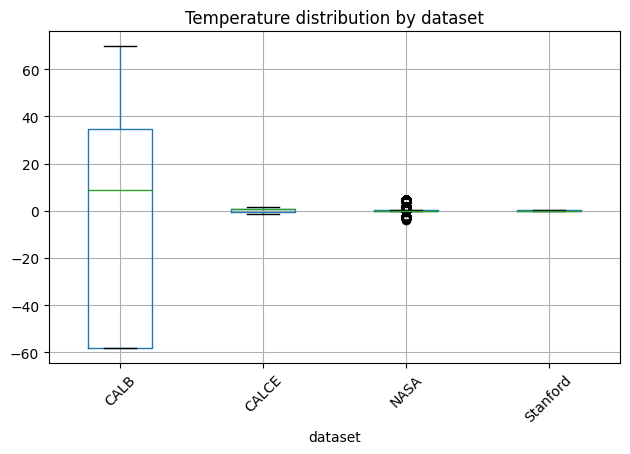

In [13]:
print("Final dataset shape:", battery_df.shape)
print("\nDataset counts:")
print(battery_df['dataset'].value_counts().head(20))

# temperature summary
display(battery_df.groupby("dataset")['temperature'].agg(['count','mean','std']).sort_values('count', ascending=False).head(20))

# small boxplot (may be heavy if dataset is huge)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
try:
    battery_df.boxplot(column='temperature', by='dataset', rot=45)
    plt.title("Temperature distribution by dataset")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped due to size / missing data:", e)

Saving sample subset for quick demos and preserve metadata linking files used.

In [14]:
# A2.12 - save metadata and small sample
metadata_df.to_csv(OUT / "dataset_metadata_used.csv", index=False)
battery_df.sample(min(2000, len(battery_df))).to_csv(OUT / "battery_sample_2k.csv", index=False)
print("Saved dataset metadata and a small sample to data_processed/")

Saved dataset metadata and a small sample to data_processed/


**Week 2 Conclusion**

1. The metadata file `data_processed/dataset_metadata_used.csv`.
2. The final dataset `battery_master_dataset.parquet` with shape and counts.
3. One or two visualizations (temperature distribution, counts per dataset).
4. Parsing was automated and reproducible.